# SHAP analysis for frontend
- It's possible to include the javascript code from the Python package on the frontend
- Work with the current "cleaned" data set from data_cleaning.py

In [1]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.feature_selection import SelectPercentile, mutual_info_classif

from sklearn.compose import make_column_transformer, ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import xgboost as xgb

import shap
# Run the following command. Needed for some visualizations.
shap.initjs();

In [2]:
RANDOM_STATE = 42

In [3]:
df = pd.read_csv('../raw_data/balanced_cleaned_378k.tsv',
                 sep='\t',
                 low_memory=False)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 378443 entries, 0 to 378442
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   B_MULTIPLE_CAE      373328 non-null  str    
 1   B_EU_FUNDS          364507 non-null  str    
 2   TOP_TYPE            377632 non-null  str    
 3   ISO_COUNTRY_CODE    378443 non-null  str    
 4   B_FRA_AGREEMENT     378443 non-null  str    
 5   B_GPA               357559 non-null  str    
 6   YEAR                378443 non-null  int64  
 7   TYPE_OF_CONTRACT    378443 non-null  str    
 8   CAE_TYPE            378443 non-null  str    
 9   CRIT_CODE           349033 non-null  str    
 10  B_ACCELERATED       378443 non-null  int64  
 11  MAIN_ACTIVITY       378439 non-null  str    
 12  CRIT_PRICE_WEIGHT   378443 non-null  float64
 13  LOTS_NUMBER         375753 non-null  float64
 14  TARGET_NOT_AWARDED  378443 non-null  int64  
dtypes: float64(2), int64(3), str(10)
memory usage

In [5]:
df.describe()

,YEAR,B_ACCELERATED,CRIT_PRICE_WEIGHT,LOTS_NUMBER,TARGET_NOT_AWARDED
count,378443.000000,378443.000000,3.784430e+05,375753.000000,378443.000000
mean,2020.644456,0.025526,5.388192e+02,8.269637,0.424436
std,1.678655,0.157715,1.846405e+05,21.935819,0.494258
min,2018.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,2019.000000,0.000000,0.000000e+00,1.000000,0.000000
50%,2021.000000,0.000000,0.000000e+00,2.000000,0.000000
75%,2022.000000,0.000000,4.000000e+01,7.000000,1.000000
max,2023.000000,1.000000,1.113875e+08,897.000000,1.000000


## Implement preprocessing.py/main.py workflow
To have the same data as currently in the code

### preprocessing.py

In [6]:
BINARY_FLAGS = ['B_MULTIPLE_CAE', 'B_EU_FUNDS', 'B_FRA_AGREEMENT', 'B_GPA', 'B_ACCELERATED']
PASS_THROUGH_FEATURES = ['CRIT_PRICE_WEIGHT', 'LOTS_NUMBER', 'YEAR', 'CRIT_CODE'] + BINARY_FLAGS
OHE_FEATURES = ['TYPE_OF_CONTRACT', 'TOP_TYPE', 'CAE_TYPE']
TARGET_ENC_FEATURES = ['ISO_COUNTRY_CODE', 'MAIN_ACTIVITY']

In [7]:
def format_features(df: pd.DataFrame) -> pd.DataFrame:
    #TODO binary features can actually all be encoded with OHE in conjunction with the categorical ones
    """Convert raw TED columns into ML-ready types (in-place safe)."""
    df = df.copy()

    # Map the procedural "B_" flags ("Y" = 1, everything else = 0) based on TED codebook [5, 6, 8]
    for col in BINARY_FLAGS:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: 1 if str(x).strip().upper() == 'Y' else 0)

    # Map CRIT_CODE based on TED rules: L (Lowest Price) = 1, M (Most economically advantageous) = 0 [7]
    if 'CRIT_CODE' in df.columns:
        df['CRIT_CODE'] = df['CRIT_CODE'].apply(lambda x: 1 if str(x).strip().upper() == 'L' else 0)

    return df

In [8]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """Build a ColumnTransformer adapted to the columns actually present in X."""
    pt_cols = [c for c in PASS_THROUGH_FEATURES if c in X.columns]
    ohe_cols = [c for c in OHE_FEATURES if c in X.columns]
    tgt_cols = [c for c in TARGET_ENC_FEATURES if c in X.columns]

    preprocessor = make_column_transformer(
        (make_pipeline(SimpleImputer(strategy='mean')), pt_cols),
        (make_pipeline(SimpleImputer(strategy='most_frequent'),
                       OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary')),
         ohe_cols),
        (make_pipeline(SimpleImputer(strategy='most_frequent'),
                       TargetEncoder()),
         tgt_cols),
        remainder='drop'
        ).set_output(transform="pandas") # added newly for the SHAP analysis

    return preprocessor

In [9]:
DEFAULT_XGB_PARAMS = {
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'random_state': RANDOM_STATE,
}

In [10]:
def build_pipeline(X: pd.DataFrame, xgb_params: dict | None = None) -> Pipeline:
    """Return a full sklearn Pipeline (preprocessor + XGBClassifier)."""
    params = xgb_params or DEFAULT_XGB_PARAMS
    preprocessor = build_preprocessor(X)
    pipeline = make_pipeline(
        preprocessor,
        xgb.XGBClassifier(**params)
    )
    return pipeline

### main.py

In [11]:
def preprocess(df: pd.DataFrame):
    """Format features and split into X, y."""
    df = format_features(df)
    # with new data, there's no target 'TARGET_NOT_AWARDED' column
    X = df.drop(columns=['TARGET_NOT_AWARDED'], errors='ignore')
    y = df['TARGET_NOT_AWARDED'] if 'TARGET_NOT_AWARDED' in df.columns else None
    return X, y

In [12]:
def train(df: pd.DataFrame, split_ratio: float = 0.2, save: bool = True):
    """
    Preprocess, train an XGBoost pipeline, evaluate, and optionally save.

    Args:
        df:          The cleaned, balanced dataframe.
        split_ratio: Fraction of data reserved for the test set (default 20%).
        save:        If True, export the trained pipeline to MODEL_PATH as .pkl.
                     Set to False (--no-save) to skip persistence.
    """
    print("\n⭐️ Use case: train")

    X, y = preprocess(df)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split_ratio, random_state=RANDOM_STATE, stratify=y
        )

    # Build the full sklearn Pipeline (ColumnTransformer + XGBClassifier)
    pipeline = build_pipeline(X_train)
    pipeline.fit(X_train, y_train)

    # Evaluation
    model_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])
    model_acc = accuracy_score(y_test, pipeline.predict(X_test))

    print(f"Model ROC AUC:      {model_auc:.4f}")
    print(f"Model Accuracy: {model_acc*100:.1f}%")

    # Conditionally save the pipeline pickle
    if save:
        save_model(pipeline)
    else:
        print("⏭️  --no-save flag: skipping .pkl export")

    print("✅ train() done\n")
    return model_auc, X_test, y_test, X_train, y_train, pipeline # newly added to get the train sets and pipeline out

In [13]:
model_auc, X_test, y_test, X_train, y_train, pipeline = train(df, save=False)


⭐️ Use case: train
Model ROC AUC:      0.6977
Model Accuracy: 65.3%
⏭️  --no-save flag: skipping .pkl export
✅ train() done



In [14]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

In [15]:
y_test_pred = pipeline.predict(X_test)

In [16]:
print(classification_report(y_test, y_test_pred, target_names=['Not Awarded', 'Awarded']))

              precision    recall  f1-score   support

 Not Awarded       0.66      0.81      0.73     43564
     Awarded       0.63      0.44      0.52     32125

    accuracy                           0.65     75689
   macro avg       0.65      0.62      0.62     75689
weighted avg       0.65      0.65      0.64     75689



In [17]:
pipeline.steps

[('columntransformer',
  ColumnTransformer(transformers=[('pipeline-1',
                                   Pipeline(steps=[('simpleimputer',
                                                    SimpleImputer())]),
                                   ['CRIT_PRICE_WEIGHT', 'LOTS_NUMBER', 'YEAR',
                                    'CRIT_CODE', 'B_MULTIPLE_CAE', 'B_EU_FUNDS',
                                    'B_FRA_AGREEMENT', 'B_GPA',
                                    'B_ACCELERATED']),
                                  ('pipeline-2',
                                   Pipeline(steps=[('simpleimputer',
                                                    SimpleImputer(strategy='most_frequent')),
                                                   ('onehotencoder',
                                                    OneHotEncoder(drop='if_binary',
                                                                  handle_unknown='ignore',
                                                   

## SHAP analysis of the results

### SHAP on one prediction - local explainability
SHAP cannot work with the pipeline layout including the imputing steps, therefore tried to extract the xgb_model out of the pipeline. However, doesn't work, as then the input variable/sample doesn't fit!

In [52]:
# get the fitted model out of there! <=> unfortunately, also didn't work for SHAP ...
xgb_model = pipeline[1] # alternatively: pipeline.steps[1][1]
xgb_model

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [19]:
X, y = preprocess(df)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
        )

In [58]:
preprocessor = pipeline[0]
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

In [56]:
# alternatively build it again, but then have to fit again
# preprocessor = build_preprocessor(X)
# preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

In [59]:
X_train_preproc = preprocessor.fit_transform(X_train, y_train)
X_test_preproc = preprocessor.transform(X_test)

In [60]:
X_train_preproc

,pipeline-1__CRIT_PRICE_WEIGHT,pipeline-1__LOTS_NUMBER,pipeline-1__YEAR,pipeline-1__CRIT_CODE,pipeline-1__B_MULTIPLE_CAE,pipeline-1__B_EU_FUNDS,pipeline-1__B_FRA_AGREEMENT,pipeline-1__B_GPA,pipeline-1__B_ACCELERATED,pipeline-2__TYPE_OF_CONTRACT_S,...,pipeline-2__CAE_TYPE_4,pipeline-2__CAE_TYPE_5,pipeline-2__CAE_TYPE_5A,pipeline-2__CAE_TYPE_6,pipeline-2__CAE_TYPE_8,pipeline-2__CAE_TYPE_N,pipeline-2__CAE_TYPE_R,pipeline-2__CAE_TYPE_Z,pipeline-3__ISO_COUNTRY_CODE,pipeline-3__MAIN_ACTIVITY
80335,0.0,11.0,2022.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.422567,0.425162
358066,0.0,1.0,2022.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.290384,0.411073
232223,0.0,7.0,2018.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.288649,0.411073
224149,0.0,1.0,2020.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.606890,0.443541
184661,0.0,3.0,2023.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.245542,0.441815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101602,0.0,1.0,2019.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.516357,0.443620
259331,0.0,1.0,2020.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.507835,0.525784
132498,0.0,7.0,2023.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.512567,0.411669
105082,0.0,2.0,2021.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.292178,0.439911


In [61]:
# for prediction need a non-processed row of X_test (<-> below SHAP analysis)
row_to_show = 0 # Select one instance to explain
feature_values = X_test.iloc[[row_to_show]]
prediction = pipeline.predict(feature_values)
print(f"{'The prediction for this instance: '}{prediction[0]}")

The prediction for this instance: 1


In [62]:
# for the xgb_model in SHAP need a preprocessed row
feature_values = X_test_preproc.iloc[[row_to_show]]

In [63]:
feature_values

,pipeline-1__CRIT_PRICE_WEIGHT,pipeline-1__LOTS_NUMBER,pipeline-1__YEAR,pipeline-1__CRIT_CODE,pipeline-1__B_MULTIPLE_CAE,pipeline-1__B_EU_FUNDS,pipeline-1__B_FRA_AGREEMENT,pipeline-1__B_GPA,pipeline-1__B_ACCELERATED,pipeline-2__TYPE_OF_CONTRACT_S,...,pipeline-2__CAE_TYPE_4,pipeline-2__CAE_TYPE_5,pipeline-2__CAE_TYPE_5A,pipeline-2__CAE_TYPE_6,pipeline-2__CAE_TYPE_8,pipeline-2__CAE_TYPE_N,pipeline-2__CAE_TYPE_R,pipeline-2__CAE_TYPE_Z,pipeline-3__ISO_COUNTRY_CODE,pipeline-3__MAIN_ACTIVITY
136770,0.0,1.0,2021.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.474938,0.410468


In [64]:
# Step 1: Create a SHAP Explainer
explainer = shap.Explainer(xgb_model)

In [65]:
# Step 2: Calculate the SHAP values
# Using the explainer we just created
# and giving as input the feature values for our instance
shap_values_one = explainer(feature_values)

In [66]:
print(len(shap_values_one.values[0]))
shap_values_one

33


.values =
array([[ 2.0408288e-01,  2.1390377e-01, -3.5984378e-02, -6.3871506e-05,
        -6.9887657e-03, -3.7958130e-02,  5.0983921e-02, -1.2273679e-02,
         0.0000000e+00,  3.8761470e-02,  3.2275025e-02, -1.3854030e-02,
         1.3898911e-02, -1.5007802e-03, -1.3520643e-04, -1.7012877e-02,
         1.1253406e-03,  3.8884729e-02,  6.8461808e-04,  1.0763218e-02,
         1.2990879e-02,  1.6143075e-03, -8.0161132e-03,  2.6483273e-03,
         8.1503938e-05, -6.2160589e-06,  6.1043366e-03, -8.1009921e-03,
         4.4980863e-04, -1.4216019e-04,  2.1054157e-05,  7.0833318e-02,
         5.7188865e-02]], dtype=float32)

.base_values =
array([-0.30769518], dtype=float32)

.data =
array([[0.00000000e+00, 1.00000000e+00, 2.02100000e+03, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 

In [68]:
shap_values_one[0]

.values =
array([ 2.0408288e-01,  2.1390377e-01, -3.5984378e-02, -6.3871506e-05,
       -6.9887657e-03, -3.7958130e-02,  5.0983921e-02, -1.2273679e-02,
        0.0000000e+00,  3.8761470e-02,  3.2275025e-02, -1.3854030e-02,
        1.3898911e-02, -1.5007802e-03, -1.3520643e-04, -1.7012877e-02,
        1.1253406e-03,  3.8884729e-02,  6.8461808e-04,  1.0763218e-02,
        1.2990879e-02,  1.6143075e-03, -8.0161132e-03,  2.6483273e-03,
        8.1503938e-05, -6.2160589e-06,  6.1043366e-03, -8.1009921e-03,
        4.4980863e-04, -1.4216019e-04,  2.1054157e-05,  7.0833318e-02,
        5.7188865e-02], dtype=float32)

.base_values =
np.float32(-0.30769518)

.data =
array([0.00000000e+00, 1.00000000e+00, 2.02100000e+03, 1.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e

In [72]:
import re
clean = re.compile(r"^[^_]+__")
features = [clean.sub("", name) for name in feature_values.columns.tolist()]
features

['CRIT_PRICE_WEIGHT',
 'LOTS_NUMBER',
 'YEAR',
 'CRIT_CODE',
 'B_MULTIPLE_CAE',
 'B_EU_FUNDS',
 'B_FRA_AGREEMENT',
 'B_GPA',
 'B_ACCELERATED',
 'TYPE_OF_CONTRACT_S',
 'TYPE_OF_CONTRACT_U',
 'TYPE_OF_CONTRACT_W',
 'TOP_TYPE_AWP',
 'TOP_TYPE_COD',
 'TOP_TYPE_INP',
 'TOP_TYPE_NIC',
 'TOP_TYPE_NIP',
 'TOP_TYPE_NOC',
 'TOP_TYPE_NOP',
 'TOP_TYPE_OPE',
 'TOP_TYPE_RES',
 'CAE_TYPE_1',
 'CAE_TYPE_3',
 'CAE_TYPE_4',
 'CAE_TYPE_5',
 'CAE_TYPE_5A',
 'CAE_TYPE_6',
 'CAE_TYPE_8',
 'CAE_TYPE_N',
 'CAE_TYPE_R',
 'CAE_TYPE_Z',
 'ISO_COUNTRY_CODE',
 'MAIN_ACTIVITY']

In [74]:
values = feature_values.iloc[0].tolist()
values

[0.0,
 1.0,
 2021.0,
 1.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.4749379715886827,
 0.41046828991987133]

In [67]:
# Have a look at these values
print(f"{'Base value: '}{shap_values_one.base_values[0]}")
print(f"{'Sum of SHAP values: '}{shap_values_one.values.sum()}")
print(f"{'The prediction for this instance: '}{prediction[0]}") # from code cell above

Base value: -0.3076951801776886
Sum of SHAP values: 0.615259051322937
The prediction for this instance: 1


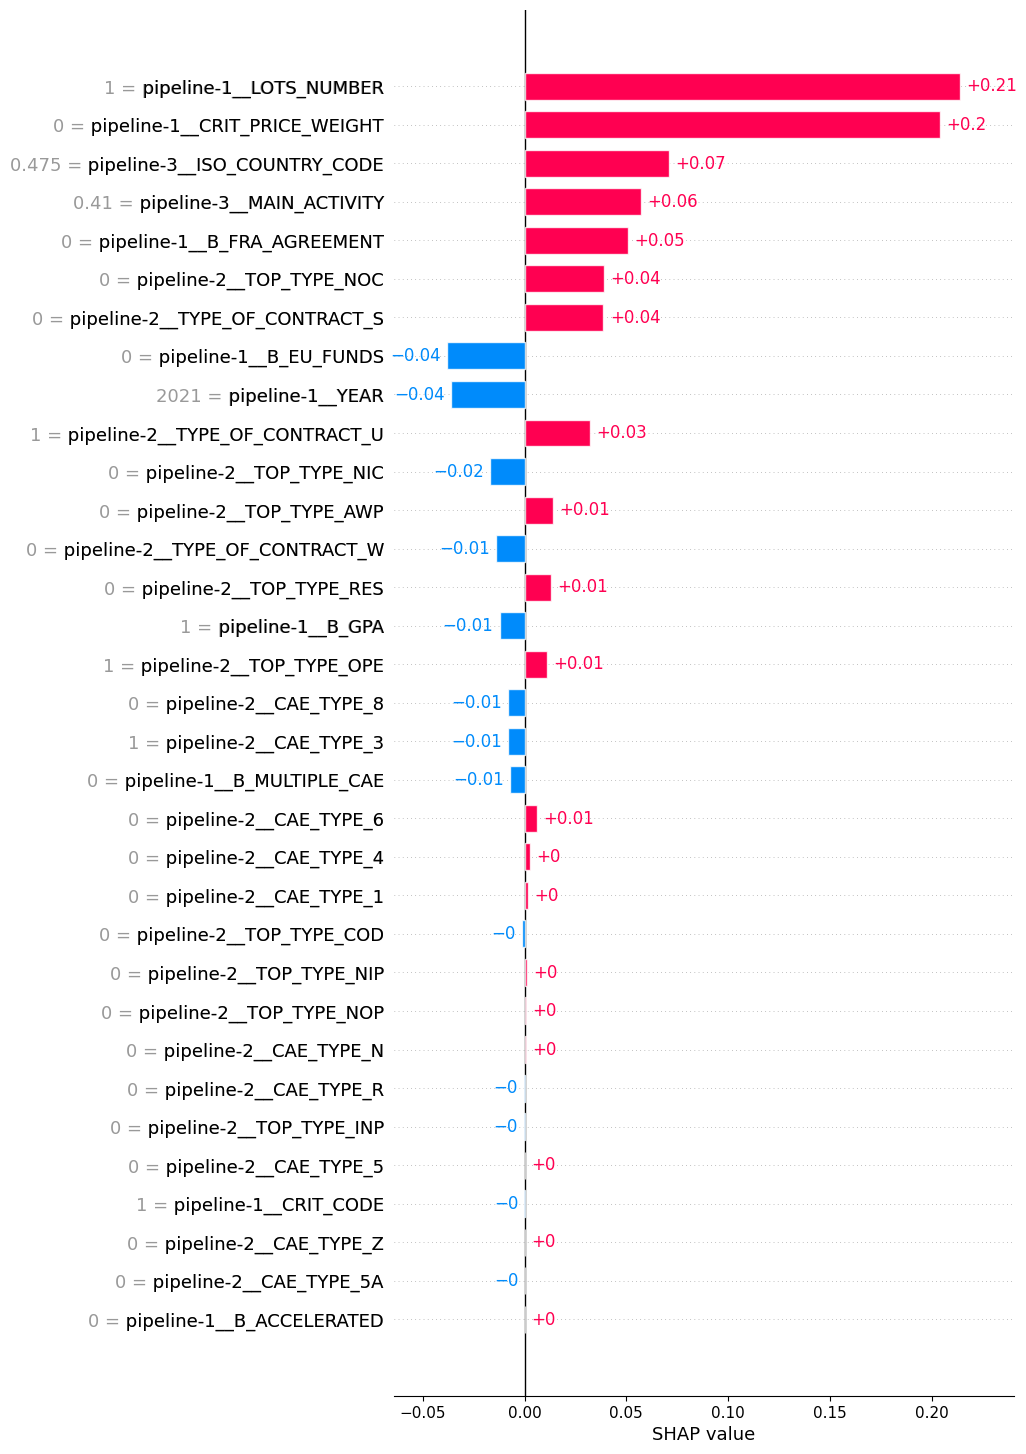

In [31]:
shap.plots.bar(shap_values_one[0], max_display=35)

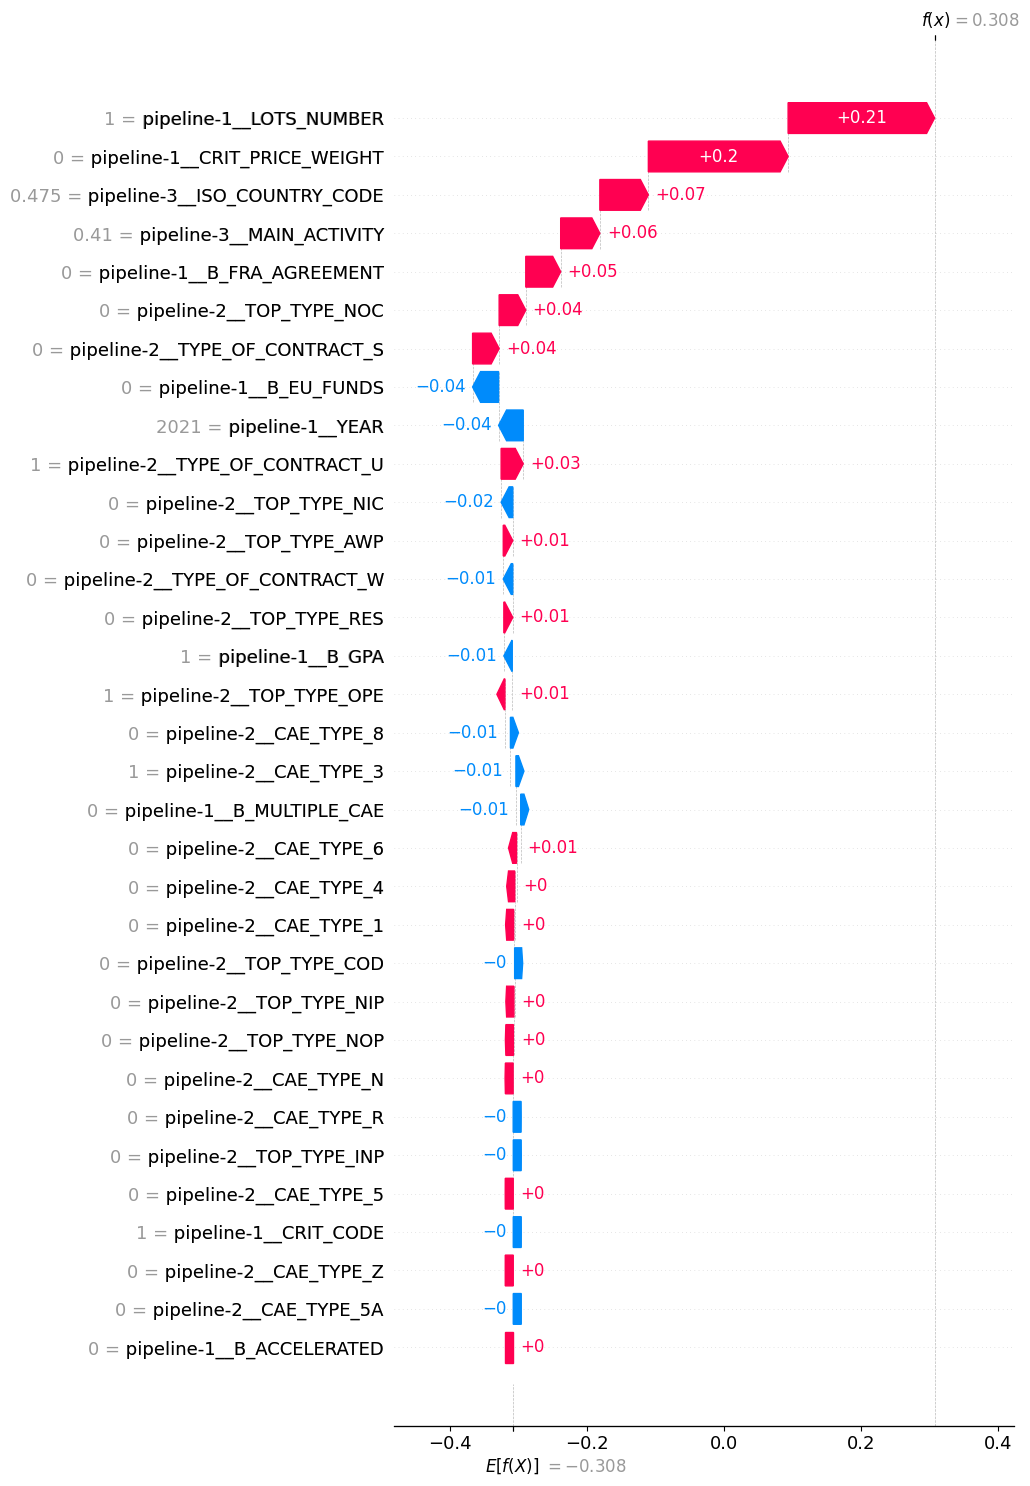

In [32]:
shap.plots.waterfall(shap_values_one[0], max_display=35)

In [33]:
shap.plots.force(shap_values_one[0])

### SHAP global explainability

In [34]:
# Let's calculate SHAP values for our whole test population
# We can use the same explainer
# This time we feed it our whole test population
shap_values = explainer(X_test_preproc)

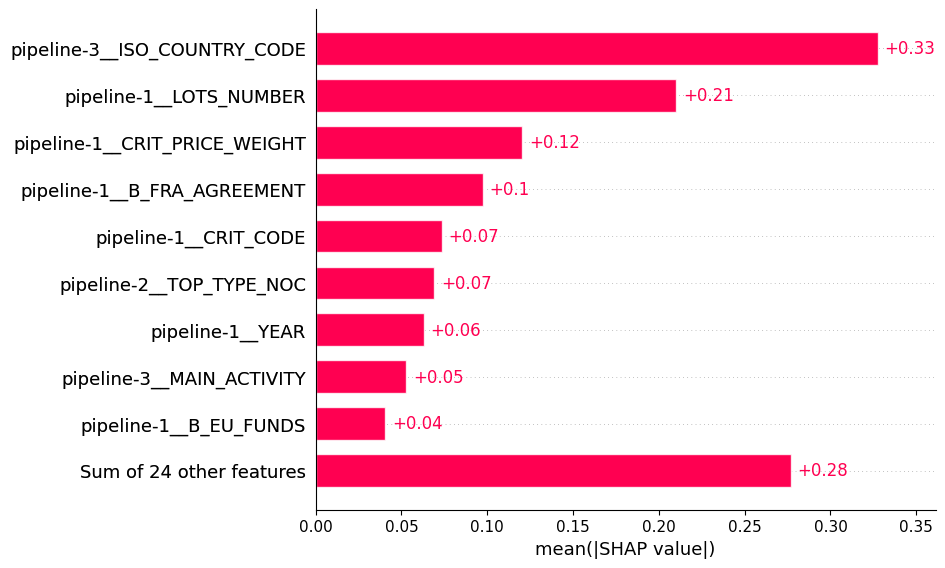

In [35]:
shap.plots.bar(shap_values)

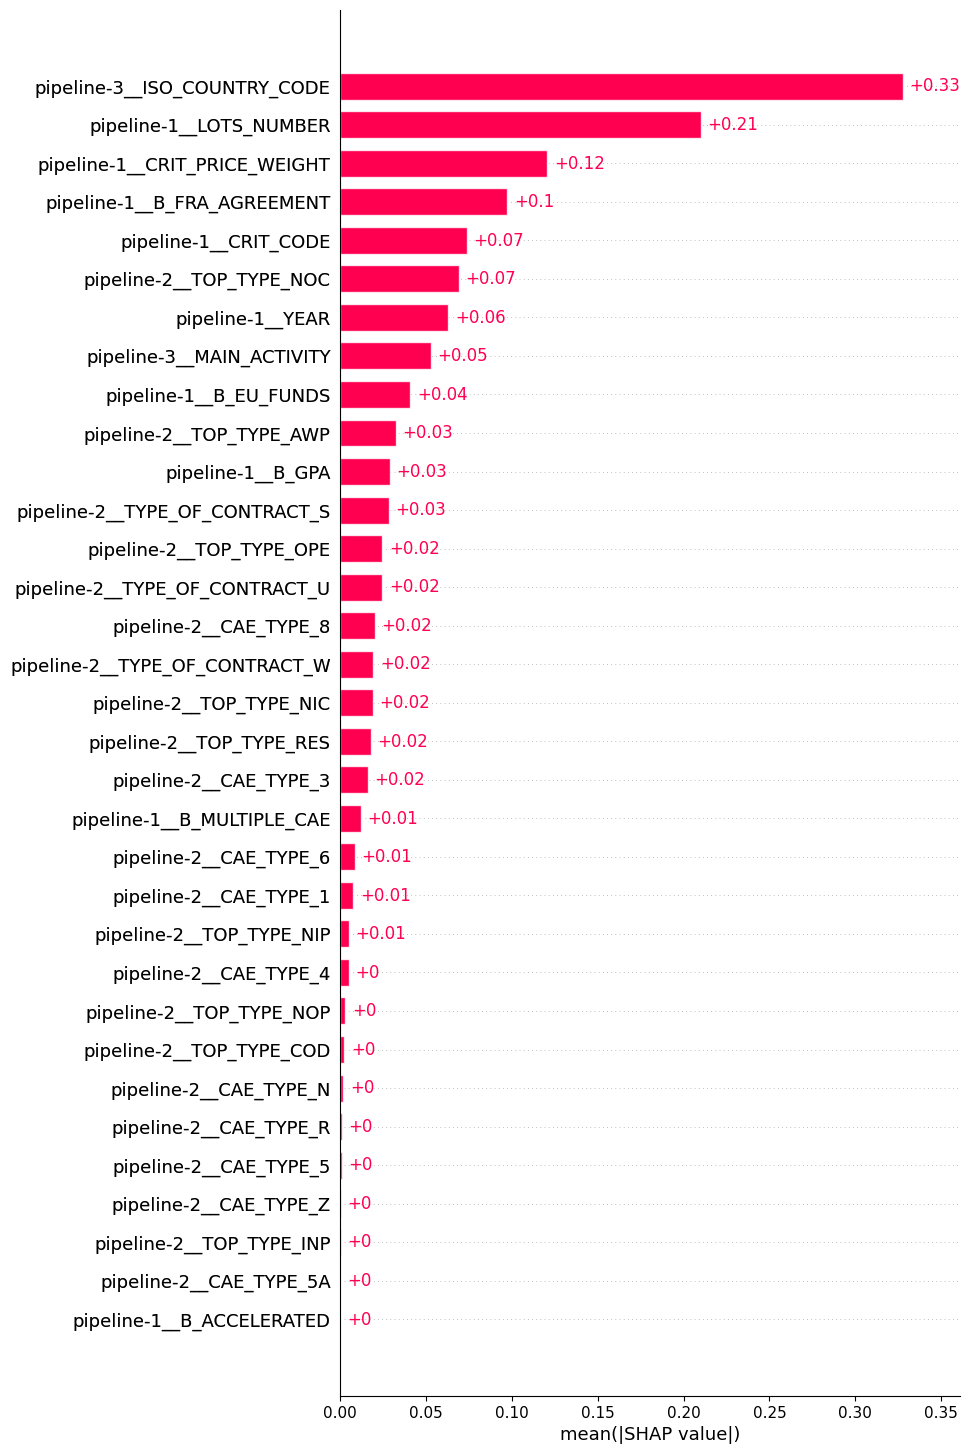

In [36]:
shap.plots.bar(shap_values, max_display=35)

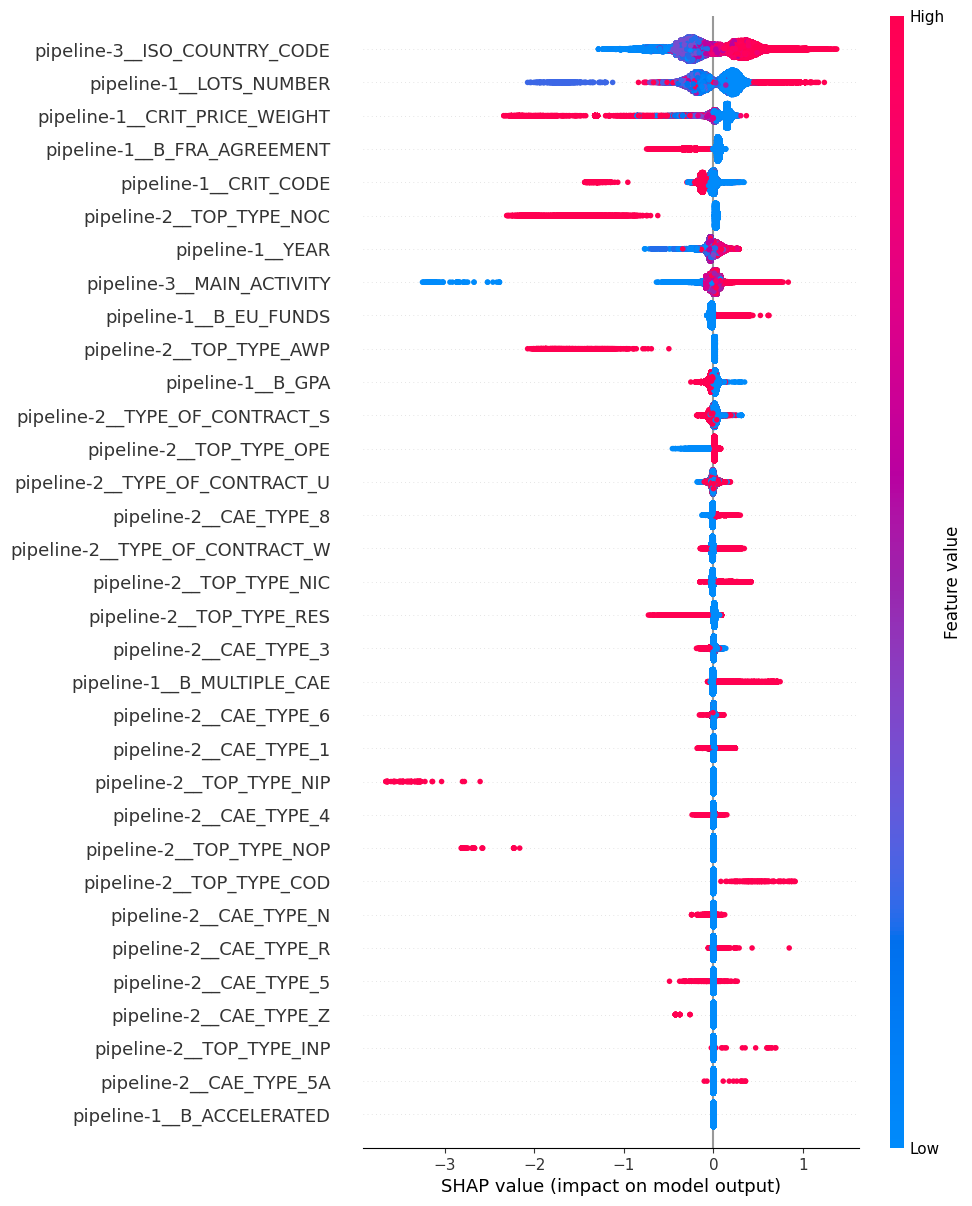

In [37]:
shap.plots.beeswarm(shap_values, max_display=35)